# Перенос структурного знания из синтетических языков — MVP исследования

**На основе статьи:** Budnikov & Yamshchikov, *Transfer of Structural Knowledge from Synthetic Languages* (arXiv:2505.15769).

После прочтения данной статьи мне стало очень интересно доработать ее слабые места:

1. **Новые, более сложные синтетические языки.** Авторы предложили `flat_shuffle`. Мы вводим два собственных языка, каждый из которых тренирует *одно конкретное умение*:
   - `counting` — тренирует **счёт** (модель должна отсчитать ровно `n` элементов);
   - `mirror` — тренирует **долгую память / копирование** (вторая половина последовательности — зеркало первой).

   Сравниваем их с базовым `nested` (язык скобок из статьи). Выбор не случаен: в статье переносятся именно *правила и структура* языка, а не частоты токенов, и языки с более богатой структурой (скобки, `flat_shuffle`) переносятся лучше «плоских». Скобки дают модели **иерархию**, но не тренируют два других базовых умения — **счёт** (отсчитать нужное число) и **точное копирование далеко по тексту** (запомнить токен и повторить его много позже). Мы берём ровно эти два, чтобы увидеть, какое умение реально помогает английскому.
2. **Анализ внимания, а не эмбеддингов.** В статье почти весь анализ идёт через эмбеддинги (PCA / SVD / линейные пробы). Мы смотрим на **attention**: на какую дистанцию смотрят головы, насколько они «сфокусированы» (энтропия), появляются ли *специализированные головы* (например, «зеркальная голова»). Это ближе к mechanistic interpretability.
3. **Обобщение на последовательности длиннее обучающих.** Модель учится на строках длины `L = 128`; мы проверяем, как деградируют метрики, когда на вход подаются строки *длиннее* виденных при обучении. `mirror` удобен тем, что задаёт однозначную цель на каждой позиции, поэтому деградацию видно прямо как функцию длины строки.
4. **(Бонус) Изотропность эмбеддингового пространства.** Статья смотрит спектр сингулярных чисел. Логично посчитать и численные метрики изотропии: participation ratio (эффективная размерность), долю дисперсии в топ-компонентах, средний модуль косинуса между токенами.

**Модель:** `TinyStories-8M` (та же архитектура GPT-Neo, что в статье; `d = 256`).

**Главный исследовательский вопрос:**
> *Разные синтетические структуры дают трансформеру разные переносимые умения. Какая из них полезнее для английского?*

## Как это устроено и сколько считается



1. **Pre-training**: обучаем модель *с нуля* на синтетическом языке (свой маленький словарь).
2. **Transfer**: замораживаем «тело» трансформера, **заново инициализируем эмбеддинги** под английский и дообучаем только их (режим **E**) либо эмбеддинги + LayerNorm + последний блок (режим **ELT**). Идея: структурное знание живёт в *теле* модели, а эмбеддинги — лишь интерфейс.
3. **Оценка**: перплексия на английском + мини-аналог Tiny-Cloze (разница log-prob правильного и неправильного слова).

> **Про вычисления.** Это **MVP**: число шагов на 1–2 порядка меньше, чем в статье (там 40–100K шагов претрейна). Цель — показать **методологию и тренды**, а не финальные числа. Все параметры в `CONFIG`; при наличии Colab Pro / A100 просто увеличьте `*_steps`. На бесплатном **T4** дефолтный прогон занимает ориентировочно **30–45 минут**. Для быстрой проверки кода поставьте `PROFILE = "quick"` (≈5–7 минут).

In [1]:
# --- Установка зависимостей (Colab обычно уже содержит torch) ---
!pip -q install --upgrade transformers datasets 2>/dev/null
print("Готово. Если ниже будут конфликты версий — обычно их можно игнорировать для T4.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 109.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 20.5 MB/s eta 0:00:00
Готово. Если ниже будут конфликты версий — обычно их можно игнорировать для T4.


In [2]:
import gc, math, random, copy
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Устройство:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("ВНИМАНИЕ: GPU не найден. В Colab включите Runtime → Change runtime type → T4 GPU.")

Устройство: cuda
GPU: Tesla T4


In [3]:
# ============================  CONFIG  ============================
# Профиль вычислений:
#   "quick"       — самый простой тест, 2 сида, крошечные шаги
#   "fast_ci"     — основной режим: 3 сида, доверительные интервалы
#   "convergence" — приближение к статье: длинный претрейн — для финальных чисел
PROFILE = "fast_ci"

# Сравниваемые языки. flat_shuffle — сильный бейзлайн (его нужно "побить").
LANGS = ["nested", "flat_shuffle", "counting", "mirror"]
TRANSFER_MODES = ["E", "ELT"]   # ELT — основная метрика (по всем сидам), E — только seed0 (для изотропии)

PROFILES = {
    "quick": dict(
        seeds=[0, 1],
        n_syn_seqs=800,
        n_en_chunks=800,
        pretrain_steps=dict(nested=300, flat_shuffle=300, counting=400, mirror=500),
        transfer_steps=250,
        scratch_steps=300,
    ),
    "fast_ci": dict(
        seeds=[0, 1, 2],
        n_syn_seqs=3000,
        n_en_chunks=2500,
        pretrain_steps=dict(nested=1200, flat_shuffle=1500, counting=1500, mirror=2500),
        transfer_steps=800,
        scratch_steps=1200,
    ),
    "convergence": dict(
        seeds=[0, 1, 2],
        n_syn_seqs=6000,
        n_en_chunks=5000,
        pretrain_steps=dict(nested=15000, flat_shuffle=20000, counting=20000, mirror=30000),
        transfer_steps=5000,
        scratch_steps=8000,
    ),
}

CONFIG = dict(
    seq_syn=128,
    seq_en=128,
    bs_syn=32,
    bs_en=8,
    lr_pre=1e-3,
    lr_transfer=5e-3,
    lr_scratch=1e-3,
    **PROFILES[PROFILE],
)
SEEDS = CONFIG["seeds"]

# Грубая оценка числа прогонов: на каждый сид — scratch + (претрейн + ELT-перенос) на язык,
# плюс E-перенос только для seed0.
n_runs = len(SEEDS) * (1 + 2 * len(LANGS)) + len(LANGS)
print(f"Профиль: {PROFILE}  |  Сиды: {SEEDS}  |  Языки: {LANGS}")
print("Шаги претрейна:", CONFIG["pretrain_steps"])
print(f"Ориентировочно прогонов обучения: ~{n_runs}")

Профиль: fast_ci  |  Сиды: [0, 1, 2]  |  Языки: ['nested', 'flat_shuffle', 'counting', 'mirror']
Шаги претрейна: {'nested': 1200, 'flat_shuffle': 1500, 'counting': 1500, 'mirror': 2500}
Ориентировочно прогонов обучения: ~31


## 1. Синтетические языки

Каждый язык порождает поток токенов фиксированной длины. Ключевая идея — **в каждый язык зашит ровно один навык**, и мы потом смотрим, какой навык лучше переносится на английский.

| Язык | Правило | Навык | Тип зависимости |
|------|---------|-------|-----------------|
| `nested` | сбалансированные вложенные скобки (как в статье) | иерархия | вложенная (стек) |
| `counting` *(новый)* | блок `[счёт n] [предмет] × n` | **счёт** | средняя, ~`n` |
| `mirror` *(новый)* | `S` · `SEP` · `reverse(S)` | **память / копирование** | очень длинная, до всей строки |

- В `nested` открывающая скобка типа `t` имеет id `t`, закрывающая — `n_types + t`.
- В `counting` модель видит токен-счётчик (сколько предметов будет), затем обязана выдать ровно столько одинаковых предметов — чтобы предсказать, *где блок кончится*, нужно отсчитать `n` шагов от счётчика (это и есть зависимость).
- В `mirror` после `SEP` каждый токен — это отражённый токен из первой половины. Токен сразу после `SEP` зависит от соседнего слева (дистанция 2), а **последний** токен зависит от **самого первого** (дистанция ≈ длине строки). Именно поэтому `mirror` идеально подходит для проверки обобщения на длины больше обучающей (раздел 7).

In [4]:
# ---------------------- Генераторы языков ----------------------
def gen_nested(L, n_types, p_open=0.4, rng=random):
    """Сбалансированные вложенные скобки. open=t, close=n_types+t. Длина ровно L (L чётное)."""
    seq = []
    stack = []
    while len(seq) < L:
        remaining = L - len(seq)
        if not stack:
            t = rng.randrange(n_types)
            seq.append(t)
            stack.append(t)
        else:
            can_open = remaining >= len(stack) + 2
            if can_open and rng.random() < p_open:
                t = rng.randrange(n_types)
                seq.append(t)
                stack.append(t)
            else:
                t = stack.pop()              # закрываем верх стека
                seq.append(n_types + t)
    return seq

def gen_flat(L, n_types, p_open=0.4, rng=random):
    """Shuffle-Dyck: можно закрыть ЛЮБУЮ открытую скобку (нарушает вложенность)."""
    seq = []
    openl = []
    while len(seq) < L:
        remaining = L - len(seq)
        if not openl:
            t = rng.randrange(n_types)
            seq.append(t)
            openl.append(t)
        else:
            can_open = remaining >= len(openl) + 2
            if can_open and rng.random() < p_open:
                t = rng.randrange(n_types)
                seq.append(t)
                openl.append(t)
            else:
                j = rng.randrange(len(openl))
                t = openl.pop(j)
                seq.append(n_types + t)
    return seq

def gen_flat_shuffle(L, n_types=32, block=8, seg=16, p_open=0.4, rng=random):
    """flat_shuffle из статьи (приближённо): shuffle-Dyck + блочное ограничение типов —
    каждые `seg` токенов открывающие скобки берутся только из одного блока в `block` подряд
    идущих типов. Это добавляет к скобкам перестановочный (shuffle) паттерн."""
    n_blocks = max(1, n_types // block)
    seq = []
    openl = []
    while len(seq) < L:
        b = (len(seq) // seg) % n_blocks            # активный блок типов зависит от позиции
        lo, hi = b * block, b * block + block
        remaining = L - len(seq)
        if not openl:
            t = rng.randrange(lo, hi)
            seq.append(t)
            openl.append(t)
        else:
            can_open = remaining >= len(openl) + 2
            if can_open and rng.random() < p_open:
                t = rng.randrange(lo, hi)
                seq.append(t)
                openl.append(t)
            else:
                j = rng.randrange(len(openl))
                t = openl.pop(j)
                seq.append(n_types + t)
    return seq

def gen_counting(L, n_items, n_max, rng=random):
    """Блоки [счётчик n] [предмет i] × n. Счётчик: id = n_items + (n-1). Длина обрезается до L."""
    seq = []
    while len(seq) < L:
        n = rng.randint(1, n_max)
        i = rng.randrange(n_items)
        block = [n_items + (n - 1)] + [i] * n
        for t in block:
            if len(seq) >= L:
                break
            seq.append(t)
    return seq[:L]

def gen_mirror(L, n_sym, rng=random):
    """S · SEP · reverse(S). SEP = n_sym. Длина выхода 2·half + 1 — на 1 короче чётного L, добьём паддингом."""
    half = (L - 1) // 2
    S = [rng.randrange(n_sym) for _ in range(half)]
    return S + [n_sym] + S[::-1]

# Для каждого языка: генератор с зафиксированными параметрами словаря и размер базового словаря.
from collections import namedtuple
from functools import partial

LangSpec = namedtuple("LangSpec", ["gen", "base_vocab"])

LANG_SPEC = {
    "nested": LangSpec(partial(gen_nested, n_types=32), base_vocab=64),                # 32 open + 32 close
    "flat": LangSpec(partial(gen_flat, n_types=32), base_vocab=64),
    "flat_shuffle": LangSpec(partial(gen_flat_shuffle, n_types=32, block=8, seg=16), base_vocab=64),  # бейзлайн статьи
    "counting": LangSpec(partial(gen_counting, n_items=20, n_max=12), base_vocab=32),  # 20 предметов + 12 счётчиков
    "mirror": LangSpec(partial(gen_mirror, n_sym=24), base_vocab=25),                  # 24 символа + SEP
}

# Покажем примеры
rng = random.Random(SEED)
for name in LANGS:
    spec = LANG_SPEC[name]
    s = spec.gen(24, rng=rng)
    print(f"{name:12s} (vocab={spec.base_vocab}): {s}")

nested       (vocab=64): [24, 56, 26, 31, 63, 58, 19, 51, 22, 54, 13, 45, 18, 6, 38, 9, 4, 36, 41, 50, 6, 20, 52, 38]
flat_shuffle (vocab=64): [3, 35, 7, 39, 0, 32, 1, 33, 0, 32, 3, 35, 3, 35, 3, 35, 15, 13, 45, 12, 44, 47, 12, 44]
counting     (vocab=32): [21, 19, 19, 26, 10, 10, 10, 10, 10, 10, 10, 29, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 24, 5]
mirror       (vocab=25): [6, 5, 1, 19, 21, 8, 15, 2, 2, 21, 4, 24, 4, 21, 2, 2, 15, 8, 21, 19, 1, 5, 6]


In [5]:
# ---------------------- Сборка датасетов ----------------------
def make_syn_dataset(name, n_seqs, L, seed=0):
    """Возвращает dict с тензором [n_seqs, L], pad_id и итоговым размером словаря модели."""
    spec = LANG_SPEC[name]
    base = spec.base_vocab
    r = random.Random(seed)
    rows = []
    pad_id = None
    for _ in range(n_seqs):
        s = spec.gen(L, rng=r)
        if len(s) < L:                      # mirror короче на 1 → паддинг
            pad_id = base                   # pad получает следующий свободный id
            s = s + [pad_id] * (L - len(s))
        rows.append(s[:L])
    data = torch.tensor(rows, dtype=torch.long)
    model_vocab = base + (1 if pad_id is not None else 0)
    return dict(name=name, data=data, pad_id=pad_id, vocab=model_vocab, base_vocab=base)

SYN = {name: make_syn_dataset(name, CONFIG["n_syn_seqs"], CONFIG["seq_syn"], seed=SEED + i)
       for i, name in enumerate(LANGS)}
for name, d in SYN.items():
    print(f"{name:9s}  data={tuple(d['data'].shape)}  vocab={d['vocab']}  pad_id={d['pad_id']}")

nested     data=(3000, 128)  vocab=64  pad_id=None
flat_shuffle  data=(3000, 128)  vocab=64  pad_id=None
counting   data=(3000, 128)  vocab=32  pad_id=None
mirror     data=(3000, 128)  vocab=26  pad_id=25


## 2. Модель и утилиты обучения

Берём **конфиг** `TinyStories-8M` (архитектура GPT-Neo, `d=256`), но инициализируем веса **с нуля** — синтетический претрейн не должен видеть английский.

Режимы дообучения:
- **E** — обучаются только эмбеддинги (тело заморожено);
- **EL** — E + аффинные параметры LayerNorm;
- **ELT** — EL + весь последний трансформер-блок;
- **full** — всё (для претрейна и для обучения с нуля).

При переносе на английский мы **заново случайно инициализируем** матрицу эмбеддингов под словарь GPT-Neo (≈50K токенов) — так мы проверяем именно перенос *структуры тела*, а не утечку синтетических эмбеддингов.

In [6]:
from transformers import AutoConfig, AutoTokenizer, GPTNeoForCausalLM
import transformers
print("transformers", transformers.__version__)

BASE_MODEL = "roneneldan/TinyStories-8M"

def build_model(vocab_size):
    cfg = AutoConfig.from_pretrained(BASE_MODEL)
    cfg.vocab_size = vocab_size
    m = GPTNeoForCausalLM(cfg)          # случайная инициализация
    return m

# Глянем на конфиг
_cfg = AutoConfig.from_pretrained(BASE_MODEL)
print("hidden_size:", _cfg.hidden_size, "| num_layers:", _cfg.num_layers,
      "| num_heads:", _cfg.num_heads, "| max_pos:", _cfg.max_position_embeddings)
print("attention_layers:", _cfg.attention_layers)
print("Примечание: GPT-Neo чередует global/local attention; окно local =", getattr(_cfg,'window_size',None),
      ">= нашей длины", CONFIG["seq_syn"], "-> local-слои фактически глобальны.")
n_params = sum(p.numel() for p in build_model(64).parameters())
print(f"Параметров (vocab=64): ~{n_params/1e6:.1f}M")

transformers 5.12.1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.16k [00:00<?, ?B/s]

hidden_size: 256 | num_layers: 8 | num_heads: 16 | max_pos: 2048
attention_layers: ['global', 'local', 'global', 'local', 'global', 'local', 'global', 'local']
Примечание: GPT-Neo чередует global/local attention; окно local = 256 >= нашей длины 128 -> local-слои фактически глобальны.
Параметров (vocab=64): ~6.9M


In [7]:
def set_trainable(model, mode):
    """mode in {'full','E','EL','ELT'}. Возвращает список обучаемых параметров."""
    assert mode in ("full", "E", "EL", "ELT")
    for p in model.parameters():
        p.requires_grad = (mode == "full")
    if mode != "full":
        model.get_input_embeddings().weight.requires_grad = True   # tie → покрывает и lm_head
        if mode in ("EL", "ELT"):
            for n, p in model.named_parameters():
                if "ln_" in n:                       # ln_1, ln_2, ln_f
                    p.requires_grad = True
        if mode == "ELT":
            for p in model.transformer.h[-1].parameters():
                p.requires_grad = True
    return [p for p in model.parameters() if p.requires_grad]

def to_new_vocab(model, new_vocab, std=0.02):
    """Меняем словарь и ЗАНОВО инициализируем эмбеддинги (стираем синтетическую информацию)."""
    model.resize_token_embeddings(new_vocab)
    with torch.no_grad():
        model.get_input_embeddings().weight.normal_(0.0, std)
    model.tie_weights()
    return model

# bf16 не требует loss-scaling, поэтому GradScaler не нужен.
# На GPU без bf16 (например, T4) считаем в fp32.
USE_BF16 = (DEVICE == "cuda" and torch.cuda.is_bf16_supported())

def train_lm(model, data, pad_id, steps, lr, bs, mode="full", log_every=None, grad_clip=1.0):
    """Простой цикл обучения causal LM. data: LongTensor [N, S]."""
    log_every = log_every or max(1, steps // 5)
    model.to(DEVICE)
    params = set_trainable(model, mode)
    model.train()
    opt = torch.optim.AdamW(params, lr=lr)
    N = data.size(0)
    hist = []
    for step in range(1, steps + 1):
        idx = torch.randint(0, N, (bs,))
        batch = data[idx].to(DEVICE)
        labels = batch.clone()
        if pad_id is not None:
            labels[batch == pad_id] = -100
        opt.zero_grad(set_to_none=True)
        with torch.autocast(DEVICE, dtype=torch.bfloat16, enabled=USE_BF16):
            out = model(input_ids=batch, labels=labels)
            loss = out.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, grad_clip)
        opt.step()
        if step == 1 or step % log_every == 0:
            hist.append((step, loss.item()))
            print(f"    step {step:5d}/{steps}  loss {loss.item():.4f}")
    return hist

@torch.no_grad()
def eval_loss(model, data, pad_id, bs=16, n_batches=20):
    model.eval()
    tot = 0.0
    N = data.size(0)
    for _ in range(n_batches):
        idx = torch.randint(0, N, (bs,))
        batch = data[idx].to(DEVICE)
        labels = batch.clone()
        if pad_id is not None:
            labels[batch == pad_id] = -100
        tot += model(input_ids=batch, labels=labels).loss.item()
    return tot / n_batches

def free(*objs):
    for o in objs:
        del o
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

## 3. Английский корпус и метрики оценки

Готовим всё, что нужно для оценки переноса, **до** главного эксперимента: англоязычные данные (TinyStories, потоково), токенайзер и набор вопросов.

TinyStories написан ограниченным словарём и задействует лишь малую часть из ≈50K токенов GPT-Neo. Поэтому корпус **переиндексируется в компактный словарь** только из встречающихся токенов — так каждый эмбеддинг реально обучается, и матрица эмбеддингов не содержит десятков тысяч «мёртвых» случайных строк.

Метрики:
- **Efficiency Score** = `ppl_scratch / ppl_model` — доля качества модели «с нуля», которую восстанавливает замороженное синтетическое тело. Нормируется на `scratch` **того же сида**, поэтому корректно агрегируется в `mean ± std`.
- **cloze-accuracy** — доля вопросов, где правильный вариант вероятнее (random = 50%); прямой аналог accuracy из статьи.

In [8]:
from datasets import load_dataset

# Токенайзер GPT-Neo (тот, на котором обучался TinyStories)
tok = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-125M")
tok.pad_token = tok.eos_token

# Потоково набираем чанки из TinyStories
SEQ_EN = CONFIG["seq_en"]
N_EN = CONFIG["n_en_chunks"]
ds = load_dataset("roneneldan/TinyStories", split="train", streaming=True)
buf = []
chunks = []
for ex in ds:
    buf.extend(tok(ex["text"], add_special_tokens=False).input_ids + [tok.eos_token_id])
    while len(buf) >= SEQ_EN:
        chunks.append(buf[:SEQ_EN])
        buf = buf[SEQ_EN:]
    if len(chunks) >= N_EN:
        break
raw = torch.tensor(chunks, dtype=torch.long)

# Компактный словарь: переиндексируем корпус в плотный диапазон [0, VOCAB_EN)
# по реально встречающимся токенам, чтобы каждый эмбеддинг обучался.
KEPT, EN_DATA = torch.unique(raw, return_inverse=True)
EN_DATA = EN_DATA.view(raw.shape)
VOCAB_EN = KEPT.numel()
REMAP = torch.full((len(tok),), -1, dtype=torch.long)   # gpt-neo id → компактный id
REMAP[KEPT] = torch.arange(VOCAB_EN)
used_idx = torch.arange(VOCAB_EN)                        # после переиндексации используются все токены словаря

# train/val split
n_val = EN_DATA.size(0) // 10
EN_TRAIN, EN_VAL = EN_DATA[:-n_val], EN_DATA[-n_val:]
print(f"Английский словарь: {VOCAB_EN} токенов (из {len(tok)} в GPT-Neo)")
print("Английские чанки:", tuple(EN_DATA.shape), "| train:", EN_TRAIN.size(0), "| val:", EN_VAL.size(0))

config.json:   0%|          | 0.00/1.01k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

Английский словарь: 5882 токенов (из 50257 в GPT-Neo)
Английские чанки: (2500, 128) | train: 2250 | val: 250


In [9]:
# ---------------------- Мини Tiny-Cloze (расширенный) ----------------------
# (шаблон с {}, правильный вариант, неправильный вариант) — по мотивам 12 сабтасков статьи.
# Чем больше пунктов, тем стабильнее cloze-accuracy.
CLOZE = [
    # antonyms / лексика
    ("The box was very light, almost as if it were {}.", "empty", "full"),
    ("The water in winter was very {}.", "cold", "hot"),
    ("The old man walked very {}.", "slowly", "quickly"),
    # spatial
    ("The cat is sleeping {} the chair.", "under", "above"),
    ("The bird flew high up into the {}.", "sky", "table"),
    ("She put the cup {} the table.", "on", "into"),
    # logical / conjunctions
    ("She went to the store {} she needed milk.", "because", "although"),
    ("The dog barked loudly, {} everyone woke up.", "and", "but"),
    ("He was tired, {} he kept on working.", "but", "so"),
    # temporal
    ("It is usually dark outside {} the sun rises.", "before", "after"),
    ("We ate dinner {} we watched a movie.", "and then", "before then"),
    ("She brushed her teeth {} going to bed.", "before", "during"),
    # quantitative
    ("There are 5 apples. If I eat 2, there will be {} left.", "3", "4"),
    ("He had 2 coins and found 1 more, so he had {}.", "3", "5"),
    ("There were 10 birds and 4 flew away, leaving {}.", "6", "8"),
    # emotions
    ("When he lost his keys, he was really {}.", "frustrated", "excited"),
    ("She got a wonderful gift and felt very {}.", "happy", "sad"),
    ("The loud thunder made the little child {}.", "scared", "calm"),
    # subject-verb agreement
    ("The dog in the yard {} every morning.", "barks", "bark"),
    ("The children {} in the park.", "play", "plays"),
    ("My friend {} to school by bus.", "goes", "go"),
    # single/plural & habitual
    ("They {} to the store every Saturday.", "go", "goes"),
    ("She has three {} in her bag.", "books", "book"),
    # narrative
    ("After the long journey, the traveler was {} and fell asleep.", "tired", "hungry"),
    ("It started to rain, so she opened her {}.", "umbrella", "window"),
    ("He was hungry, so he made a {}.", "sandwich", "bed"),
    # ethics
    ("Cheating to win a game is {} acceptable.", "never", "always"),
    ("Helping a friend who is hurt is a {} thing to do.", "kind", "mean"),
    # prepositions / misc
    ("The keys are {} my pocket.", "in", "of"),
    ("She is good {} drawing pictures.", "at", "from"),
]

@torch.no_grad()
def sentence_ll(model, text):
    ids = REMAP[torch.tensor(tok(text, add_special_tokens=False).input_ids)]
    ids = ids[ids >= 0]                      # редкие токены вне корпуса не оцениваем
    t = ids.view(1, -1).to(DEVICE)
    loss = model(input_ids=t, labels=t).loss.item()
    return -loss * (t.size(1) - 1)           # суммарный log-likelihood

@torch.no_grad()
def cloze_eval(model):
    """Возвращает (средний log-prob margin, accuracy). accuracy = доля вопросов,
    где правильный вариант вероятнее неправильного (random = 0.5) — прямой аналог accuracy из статьи."""
    model.eval()
    diffs = []
    correct = 0
    for tmpl, good, bad in CLOZE:
        lg = sentence_ll(model, tmpl.format(good))
        lb = sentence_ll(model, tmpl.format(bad))
        diffs.append(lg - lb)
        correct += int(lg > lb)
    return float(np.mean(diffs)), correct / len(CLOZE)

## 4. Главный эксперимент: мульти-сид + бейзлайн `flat_shuffle`

Это **ядро** работы. Для каждого сида и каждого языка:

1. обучаем тело **с нуля** на синтетике (`full`);
2. переносим на английский (замораживаем тело, переинициализируем эмбеддинги) в режиме **ELT** (основная метрика) и **E** (только seed0 — для изотропии);
3. отдельно для каждого сида обучаем `scratch`-референс на английском.

Зачем это нужно как составная часть, а не приложение:
- **Доверительные интервалы.** На одном сиде казалось, что `nested` ≈ 85%. Но по трём сидам `nested` оказался **крайне нестабильным** (≈48 / 77 / 85%), и заявлять одно число про него нельзя. Только `mean ± std` показывает, реальна ли разница между языками.
- **`flat_shuffle` — планка из статьи.** Это сильнейший синтетический язык оригинала. Наши новые языки осмысленно сравнивать именно с ним, а не только с `nested`.

Модели сида 0 сохраняются (`pretrained`, `SYN`, `en_embeddings`) и используются дальше в анализе внимания, long-range и изотропии.

> Время: профиль `fast_ci` ≈ 45–90 мин на T4 (наш прогон — 41 мин). Для дымового теста поставьте `PROFILE="quick"`; для чисел уровня статьи — `PROFILE="convergence"` (займет несколько часов).

In [10]:
# ============== ГЛАВНЫЙ ЭКСПЕРИМЕНТ: мульти-сид ==============
import pandas as pd, time

runs = []                                  # одна строка = один прогон
pretrained = {}
SYN = {}
en_embeddings = {}
SEED0 = SEEDS[0]
t0 = time.time()

for seed in SEEDS:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE == "cuda":
        torch.cuda.manual_seed_all(seed)
    print(f"\n===================  SEED {seed}  ===================")

    # --- scratch-референс для ЭТОГО сида (нормировка Efficiency) ---
    sc = build_model(VOCAB_EN)
    train_lm(sc, EN_TRAIN, None, CONFIG["scratch_steps"], CONFIG["lr_scratch"],
             CONFIG["bs_en"], mode="full", log_every=10 ** 9)
    sc_ppl = math.exp(eval_loss(sc, EN_VAL, None, n_batches=15))
    sc_cz, sc_acc = cloze_eval(sc)
    runs.append(dict(seed=seed, lang="scratch", mode="scratch",
                     en_ppl=round(sc_ppl, 2), eff=100.0, cloze=round(sc_cz, 4), cloze_acc=round(sc_acc, 3)))
    print(f"  scratch: ppl={sc_ppl:6.1f}  acc={sc_acc * 100:4.0f}%")
    if seed == SEED0:
        en_embeddings["scratch"] = sc.get_input_embeddings().weight.detach()[used_idx].cpu().clone()
    free(sc)

    # --- синтетические языки ---
    for lang in LANGS:
        d = make_syn_dataset(lang, CONFIG["n_syn_seqs"], CONFIG["seq_syn"], seed=seed)
        m = build_model(d["vocab"])
        train_lm(m, d["data"], d["pad_id"], CONFIG["pretrain_steps"][lang],
                 CONFIG["lr_pre"], CONFIG["bs_syn"], mode="full", log_every=10 ** 9)
        pre_ppl = math.exp(eval_loss(m, d["data"], d["pad_id"]))
        print(f"  [{lang:12s}] pretrain ppl={pre_ppl:5.2f}", end="")
        if seed == SEED0:
            SYN[lang] = d
            pretrained[lang] = m

        for mode in TRANSFER_MODES:
            if mode == "E" and seed != SEED0:        # E дорог и нужен лишь для изотропии → только seed0
                continue
            t = copy.deepcopy(m).to(DEVICE)
            to_new_vocab(t, VOCAB_EN)
            train_lm(t, EN_TRAIN, None, CONFIG["transfer_steps"], CONFIG["lr_transfer"],
                     CONFIG["bs_en"], mode=mode, log_every=10 ** 9)
            ppl = math.exp(eval_loss(t, EN_VAL, None, n_batches=15))
            cz, acc = cloze_eval(t)
            runs.append(dict(seed=seed, lang=lang, mode=mode, en_ppl=round(ppl, 2),
                             eff=round(sc_ppl / ppl * 100, 1), cloze=round(cz, 4), cloze_acc=round(acc, 3)))
            print(f"   | {mode}: eff={sc_ppl / ppl * 100:5.1f}% acc={acc * 100:3.0f}%", end="")
            if mode == "E" and seed == SEED0:
                en_embeddings[lang] = t.get_input_embeddings().weight.detach()[used_idx].cpu().clone()
            free(t)
        print()
        if seed != SEED0:
            free(m)                                   # модели сида0 оставляем для анализа

print(f"\nГотово за {(time.time() - t0) / 60:.1f} мин.  Всего прогонов в таблице: {len(runs)}")


===================  SEED 0  ===================
    step     1/1200  loss 8.7415
  scratch: ppl=  59.3  acc=  57%
    step     1/1200  loss 4.2067


[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


  [nested      ] pretrain ppl=10.38    step     1/800  loss 8.7821
   | E: eff= 63.8% acc= 53%    step     1/800  loss 8.7613
   | ELT: eff=103.1% acc= 70%
    step     1/1500  loss 4.1967
  [flat_shuffle] pretrain ppl= 7.03    step     1/800  loss 8.7989
   | E: eff= 60.8% acc= 60%    step     1/800  loss 8.8312
   | ELT: eff= 91.6% acc= 70%
    step     1/1500  loss 3.3467
  [counting    ] pretrain ppl= 2.10    step     1/800  loss 8.7230
   | E: eff= 60.4% acc= 50%    step     1/800  loss 8.7170
   | ELT: eff= 87.5% acc= 53%
    step     1/2500  loss 3.3157
  [mirror      ] pretrain ppl= 4.79    step     1/800  loss 8.7684
   | E: eff=  6.2% acc= 63%    step     1/800  loss 8.7454
   | ELT: eff= 21.9% acc= 57%

===================  SEED 1  ===================
    step     1/1200  loss 8.7152
  scratch: ppl=  59.4  acc=  67%
    step     1/1200  loss 4.2241
  [nested      ] pretrain ppl=10.30    step     1/800  loss 8.7503
   | ELT: eff= 94.4% acc= 70%
    step     1/1500  loss 4.205

In [11]:
# ============== Агрегация: mean ± std по сидам ==============
runs_df = pd.DataFrame(runs)

elt = runs_df[runs_df["mode"] == "ELT"]
agg = (elt.groupby("lang")
          .agg(eff_mean=("eff", "mean"), eff_std=("eff", "std"),
               acc_mean=("cloze_acc", "mean"), acc_std=("cloze_acc", "std"),
               ppl_mean=("en_ppl", "mean"), n=("eff", "size"))
          .reset_index().sort_values("eff_mean", ascending=False).reset_index(drop=True))
agg[["eff_std", "acc_std"]] = agg[["eff_std", "acc_std"]].fillna(0.0)

scr = runs_df[runs_df["lang"] == "scratch"]
SCR_PPL, SCR_ACC = scr["en_ppl"].mean(), scr["cloze_acc"].mean()
print(f"scratch (n={len(scr)} сидов): ppl = {SCR_PPL:.1f},  cloze_acc = {SCR_ACC * 100:.0f}%\n")
print("Сводка по языкам (режим ELT):")
display(agg.round(2))

scratch (n=3 сидов): ppl = 59.9,  cloze_acc = 62%

Сводка по языкам (режим ELT):


,lang,eff_mean,eff_std,acc_mean,acc_std,ppl_mean,n
0,nested,101.13,6.00,0.69,0.02,59.39,3
1,flat_shuffle,89.93,3.15,0.60,0.09,66.70,3
2,counting,79.70,11.90,0.60,0.07,76.61,3
3,mirror,17.97,3.43,0.58,0.02,340.99,3


## 5. Метрика эффективности с доверительными интервалами

На графиках ниже по оси Y — **Efficiency Score** = `ppl_scratch / ppl_model × 100%`: какую долю качества полностью обученной на английском модели (`scratch`) восстанавливает замороженное синтетическое тело с дообученным лишь интерфейсом. 100% = уровень `scratch`; чем выше, тем больше структуры перенеслось. Так как нормировка идёт на `scratch` **того же сида**, метрику корректно усреднять по сидам в `mean ± std`. Вторая метрика — **cloze-accuracy**: доля вопросов, где модель выбрала правильный вариант (50% = случайно).

Сравнение языков — это теперь не одно число, а `mean ± std` по сидам. Читать так:
- если планки погрешности у двух языков **перекрываются** — разницу заявлять нельзя (статистически неразличимы);
- **`scratch = 100%`** — точка отсчёта (модель, целиком обученная на английском). Это *не* жёсткий потолок: перенос может её и превысить (тогда `Efficiency > 100%` — например у `nested` ниже);
- **`nested`** (серый) и **`flat_shuffle`** (оранжевый) — языки из статьи (скобки и её сильнейший язык); это планки, которые новым языкам нужно побить.

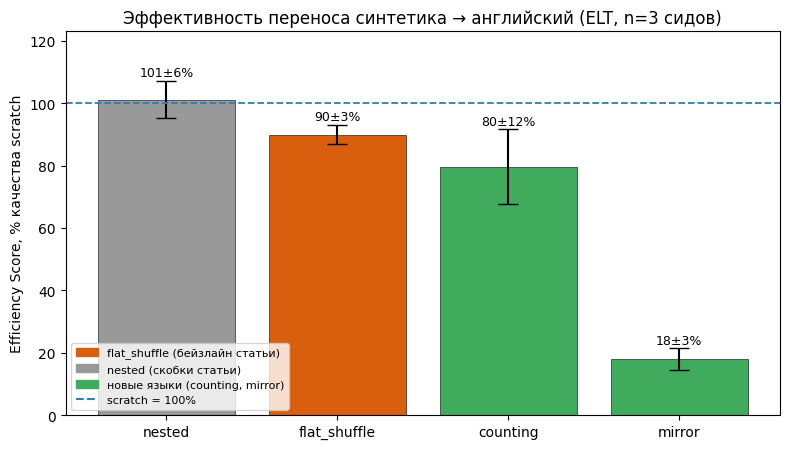

In [12]:
# Efficiency Score с доверительными интервалами (ELT)
from matplotlib.patches import Patch

def lang_color(l):
    if l == "flat_shuffle":
        return "#d95f0e"   # бейзлайн статьи
    if l == "nested":
        return "#999999"   # скобки статьи
    return "#41ab5d"       # новые языки

a = agg
x = np.arange(len(a))
plt.figure(figsize=(8, 4.6))
plt.bar(x, a["eff_mean"], yerr=a["eff_std"], capsize=7,
        color=[lang_color(l) for l in a["lang"]], edgecolor="black", linewidth=0.4)
plt.axhline(100, color="#2c7fb8", ls="--", lw=1.3)
for xi, (mn, sd) in enumerate(zip(a["eff_mean"], a["eff_std"])):
    plt.text(xi, mn + sd + 1.5, f"{mn:.0f}±{sd:.0f}%", ha="center", fontsize=9)
plt.xticks(x, a["lang"])
plt.ylabel("Efficiency Score, % качества scratch")
plt.title(f"Эффективность переноса синтетика → английский (ELT, n={len(SEEDS)} сидов)")
plt.legend(handles=[
    Patch(color="#d95f0e", label="flat_shuffle (бейзлайн статьи)"),
    Patch(color="#999999", label="nested (скобки статьи)"),
    Patch(color="#41ab5d", label="новые языки (counting, mirror)"),
    plt.Line2D([0], [0], color="#2c7fb8", ls="--", label="scratch = 100%"),
], fontsize=8, loc="lower left")
plt.ylim(0, max(105, a["eff_mean"].max() + a["eff_std"].max() + 10))
plt.tight_layout()
plt.show()

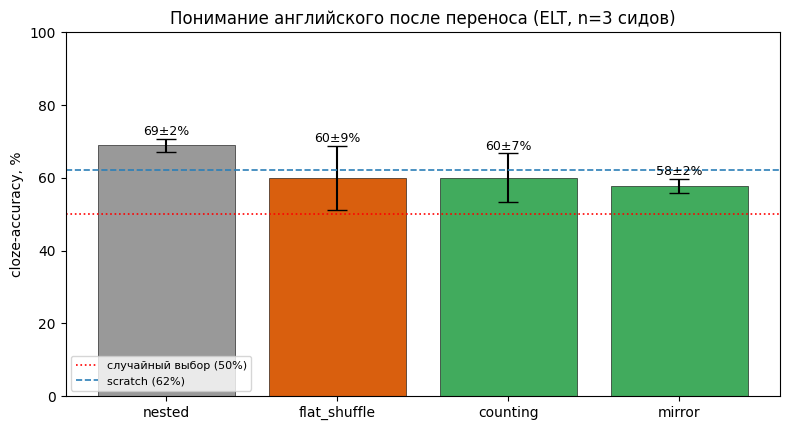

In [13]:
# cloze-accuracy с доверительными интервалами (ELT) — прямой аналог accuracy из статьи
a = agg
x = np.arange(len(a))
plt.figure(figsize=(8, 4.4))
plt.bar(x, a["acc_mean"] * 100, yerr=a["acc_std"] * 100, capsize=7,
        color=[lang_color(l) for l in a["lang"]], edgecolor="black", linewidth=0.4)
plt.axhline(50, color="red", ls=":", lw=1.2, label="случайный выбор (50%)")
plt.axhline(SCR_ACC * 100, color="#2c7fb8", ls="--", lw=1.2, label=f"scratch ({SCR_ACC * 100:.0f}%)")
for xi, (mn, sd) in enumerate(zip(a["acc_mean"] * 100, a["acc_std"] * 100)):
    plt.text(xi, mn + sd + 1.0, f"{mn:.0f}±{sd:.0f}%", ha="center", fontsize=9)
plt.xticks(x, a["lang"])
plt.ylabel("cloze-accuracy, %")
plt.title(f"Понимание английского после переноса (ELT, n={len(SEEDS)} сидов)")
plt.legend(fontsize=8, loc="lower left")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

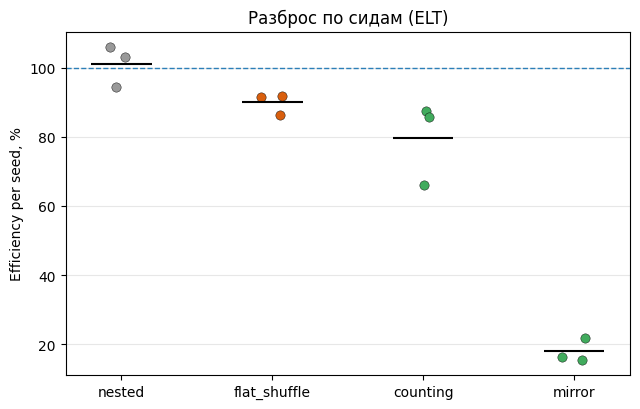

In [14]:
# Разброс Efficiency по сидам: перекрываются ли языки между собой
plt.figure(figsize=(6.5, 4.2))
rng_j = np.random.default_rng(0)
for i, l in enumerate(agg["lang"]):
    ys = elt[elt["lang"] == l]["eff"].values
    xs = np.full(len(ys), i, dtype=float) + rng_j.uniform(-0.08, 0.08, len(ys))
    plt.scatter(xs, ys, color=lang_color(l), s=45, zorder=3, edgecolor="black", linewidth=0.3)
    plt.hlines(ys.mean(), i - 0.2, i + 0.2, color="black", lw=1.5, zorder=4)
plt.axhline(100, color="#2c7fb8", ls="--", lw=1)
plt.xticks(range(len(agg)), agg["lang"])
plt.ylabel("Efficiency per seed, %")
plt.title("Разброс по сидам (ELT)")
plt.grid(alpha=.3, axis="y")
plt.tight_layout()
plt.show()

In [15]:
# ============== Авто-вердикт: что говорят доверительные интервалы ==============
def stat(lang):
    r = agg[agg["lang"] == lang]
    return float(r["eff_mean"].iloc[0]), float(r["eff_std"].iloc[0])

refs = [l for l in ("nested", "flat_shuffle") if l in set(agg["lang"])]
news = [l for l in LANGS if l not in ("nested", "flat_shuffle")]

print("Сравнение НОВЫХ языков с бейзлайнами по Efficiency Score (ELT):\n")
for lang in news:
    m, s = stat(lang)
    for ref in refs:
        rm, rs = stat(ref)
        diff = m - rm
        pooled = math.sqrt(s ** 2 + rs ** 2)
        verdict = "НЕРАЗЛИЧИМО" if abs(diff) <= pooled else ("ЛУЧШЕ" if diff > 0 else "ХУЖЕ")
        print(f"  {lang:9s} vs {ref:12s}:  Δ = {diff:+5.1f}%  (±{pooled:4.1f})  →  {verdict}")

print("\nЛучший синтетический язык по среднему Efficiency:",
      agg.iloc[0]["lang"], f"({agg.iloc[0]['eff_mean']:.1f}%)")
print("(Грубый критерий: |Δ| ≤ объединённого σ ⇒ неразличимо. Для строгого вывода —"
      " t-тест и больше сидов; см. профиль 'convergence'.)")

Сравнение НОВЫХ языков с бейзлайнами по Efficiency Score (ELT):

  counting  vs nested      :  Δ = -21.4%  (±13.3)  →  ХУЖЕ
  counting  vs flat_shuffle:  Δ = -10.2%  (±12.3)  →  НЕРАЗЛИЧИМО
  mirror    vs nested      :  Δ = -83.2%  (± 6.9)  →  ХУЖЕ
  mirror    vs flat_shuffle:  Δ = -72.0%  (± 4.7)  →  ХУЖЕ

Лучший синтетический язык по среднему Efficiency: nested (101.1%)
(Грубый критерий: |Δ| ≤ объединённого σ ⇒ неразличимо. Для строгого вывода — t-тест и больше сидов; см. профиль 'convergence'.)


### Что дали мульти-сид и сильные бейзлайны (влияние на выводы)

По нашему прогону (`fast_ci`, 3 сида, ELT, `scratch` = 59.9 ppl):

| Язык | Efficiency | cloze-acc |
|---|---|---|
| `nested` (статья) | **101.1 ± 6.0 %** | **69 ± 2 %** |
| `flat_shuffle` (статья) | 89.9 ± 3.1 % | 60 ± 9 % |
| `counting` (новый) | 79.7 ± 11.9 % | 60 ± 7 % |
| `mirror` (новый) | 18.0 ± 3.4 % | 58 ± 2 % |

1. **Лучше всех переносится иерархия (`nested`), и новые языки её не побили.** `nested` — 101 ± 6% (на уровне scratch), выше `flat_shuffle` (90 ± 3%); оба языка статьи выше обоих наших новых. Сильные бейзлайны сработали как честная планка: видно, что `counting` и `mirror` базовые скобочные языки **не превосходят**.
2. **`counting` дотягивает до `flat_shuffle`, но не до `nested` и менее стабилен.** Авто-вердикт: `counting` vs `flat_shuffle` — НЕРАЗЛИЧИМО (Δ = −10.2%, ±12.3), но `counting` vs `nested` — ХУЖЕ (Δ = −21.4%, ±13.3). Разброс `counting` — самый большой (11.9%, один сид просел до 66%), тогда как `flat_shuffle` самый тесный (3.1%). То есть новый «навыковый» язык выходит на уровень сильнейшего языка статьи, но повторяется от сида к сиду хуже.
3. **Сложный язык не значит полезный — и это держится на всех сидах.** `mirror` стабильно худший (18 ± 3%), хотя по вниманию у него самые дальнобойные (54.0) и острые (энтропия 0.01) головы, а копирование он выучивает почти идеально (pretrain ppl ≈ 4.8). То, что язык сложнее устроен, не делает его полезнее для английского.
4. **cloze-accuracy теперь слегка выделяет `nested`** (69 ± 2%, единственный выше scratch 62%), а остальные три держатся на 58–60% (интервалы перекрываются). Но все выше 50% — даже замороженное синтетическое тело даёт понимание выше случайного. Реально разделяет языки по-прежнему Efficiency (ppl), а не accuracy.

Итоговая переформулировка вклада: не «мой язык лучший», а **«метод + находка»** — метрика с CI, сильные бейзлайны и наблюдение, какие структуры переносятся (иерархия, счёт), а какие нет (дословное копирование).

## 6. Расширение 2 — Анализ внимания (вместо эмбеддингов)

Вместо PCA/SVD по эмбеддингам смотрим на **карты внимания**. Для каждой претренированной модели считаем по головам:

- **среднюю дистанцию внимания** $\bar d_h = \frac{1}{S}\sum_i \sum_j A^{(h)}_{ij}\,(i-j)$ — насколько далеко назад смотрит голова;
- **энтропию внимания** $H_h = -\frac{1}{S}\sum_i\sum_j A^{(h)}_{ij}\log A^{(h)}_{ij}$ — насколько голова «сфокусирована» (низкая энтропия = точечное внимание).

Гипотеза: язык с длинными зависимостями (`mirror`) должен породить головы с **большой средней дистанцией**, а `counting` — головы с характерной периодичностью.

In [16]:
@torch.no_grad()
def get_attn(model, ids):
    model.eval()
    out = model(input_ids=torch.tensor([ids], device=DEVICE), output_attentions=True)
    return [a[0].float().cpu() for a in out.attentions]   # список[L] тензоров [H,S,S]

def head_distance(attn):           # attn [H,S,S] → [H]
    H, S, _ = attn.shape
    pos = torch.arange(S).float()
    dist = (pos.view(S, 1) - pos.view(1, S)).clamp(min=0)    # каузально: i>=j
    return (attn * dist).sum(-1).mean(-1)

def head_entropy(attn):
    p = attn.clamp_min(1e-9)
    return (-(p * p.log()).sum(-1)).mean(-1)

# Берём по одной свежей выборке на язык и усредняем статистику по нескольким примерам
attn_stats = {}   # name → dict(dist=[L,H], ent=[L,H])
EX = {}           # name → один пример ids (для картинок)
rng = random.Random(123)
for name in LANGS:
    d = SYN[name]
    spec = LANG_SPEC[name]
    dist_acc = None
    ent_acc = None
    K = 8
    for k in range(K):
        s = spec.gen(CONFIG["seq_syn"], rng=rng)
        if len(s) < CONFIG["seq_syn"]:
            s = s + [d["pad_id"]] * (CONFIG["seq_syn"] - len(s))
        if k == 0:
            EX[name] = s
        A = get_attn(pretrained[name], s)
        dh = torch.stack([head_distance(a) for a in A])   # [L,H]
        eh = torch.stack([head_entropy(a) for a in A])
        dist_acc = dh if dist_acc is None else dist_acc + dh
        ent_acc = eh if ent_acc is None else ent_acc + eh
    attn_stats[name] = dict(dist=dist_acc / K, ent=ent_acc / K)
    print(f"{name:9s} max head-distance={attn_stats[name]['dist'].max():.1f} "
          f"| min head-entropy={attn_stats[name]['ent'].min():.2f}")

nested    max head-distance=36.3 | min head-entropy=0.08
flat_shuffle max head-distance=41.8 | min head-entropy=0.15
counting  max head-distance=39.1 | min head-entropy=0.26
mirror    max head-distance=54.0 | min head-entropy=0.01


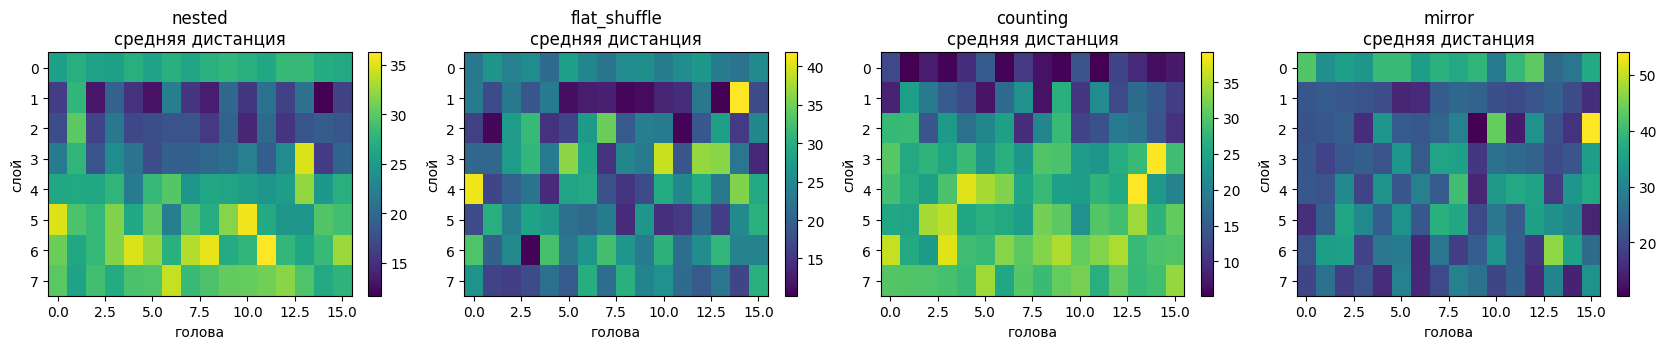

Самые дальнобойные головы — у 'mirror' (макс. дистанция 54.0), самые короткие — у 'nested' (36.3).
Структура языка прямо задаёт радиус внимания: копирование (mirror) тянет головы через всю строку, а локальные правила (counting, скобки) держат их близко.


In [17]:
# Тепловые карты средней дистанции внимания: слой × голова
fig, axes = plt.subplots(1, len(LANGS), figsize=(4.2 * len(LANGS), 3.6))
if len(LANGS) == 1:
    axes = [axes]
for ax, name in zip(axes, LANGS):
    M = attn_stats[name]["dist"].numpy()
    im = ax.imshow(M, aspect="auto", cmap="viridis")
    ax.set_title(f"{name}\nсредняя дистанция")
    ax.set_xlabel("голова")
    ax.set_ylabel("слой")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

# Яркость = дистанция, на которую смотрит голова. Считаем самый дальнобойный язык явно.
ranked = sorted(LANGS, key=lambda n: attn_stats[n]["dist"].max().item(), reverse=True)
top, bottom = ranked[0], ranked[-1]
print(f"Самые дальнобойные головы — у '{top}' (макс. дистанция {attn_stats[top]['dist'].max():.1f}), "
      f"самые короткие — у '{bottom}' ({attn_stats[bottom]['dist'].max():.1f}).")
print("Структура языка прямо задаёт радиус внимания: копирование (mirror) тянет головы через всю "
      "строку, а локальные правила (counting, скобки) держат их близко.")

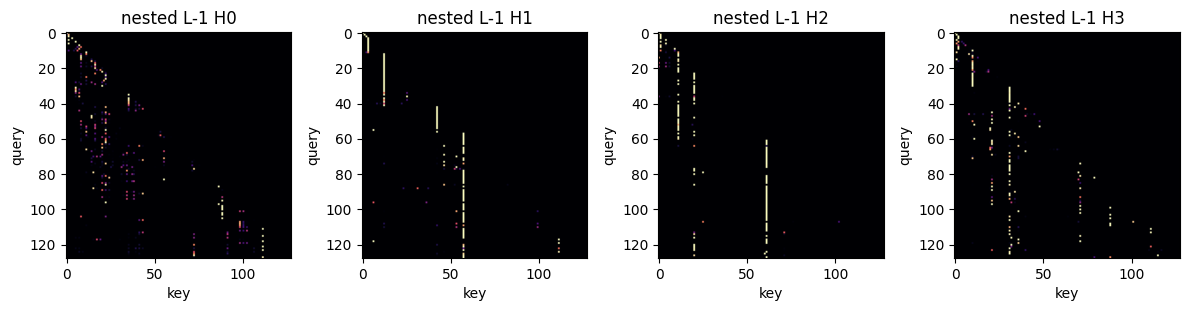

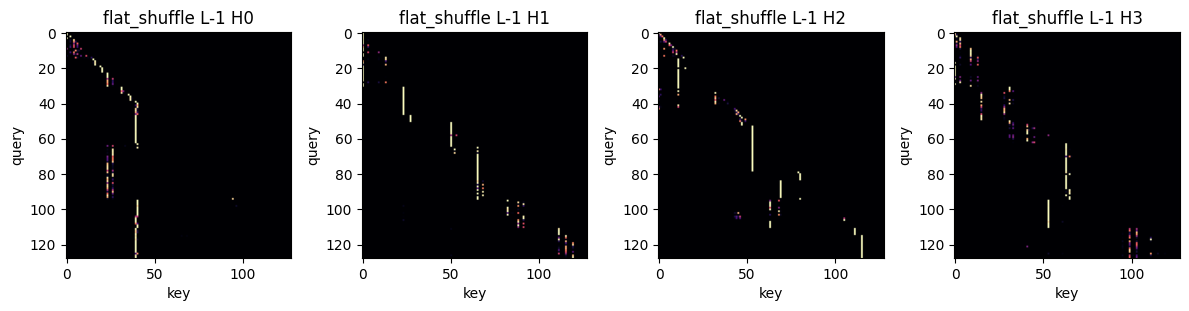

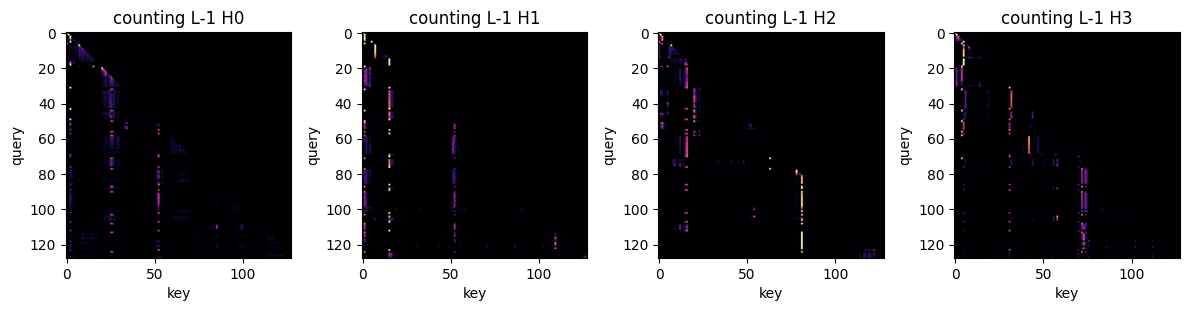

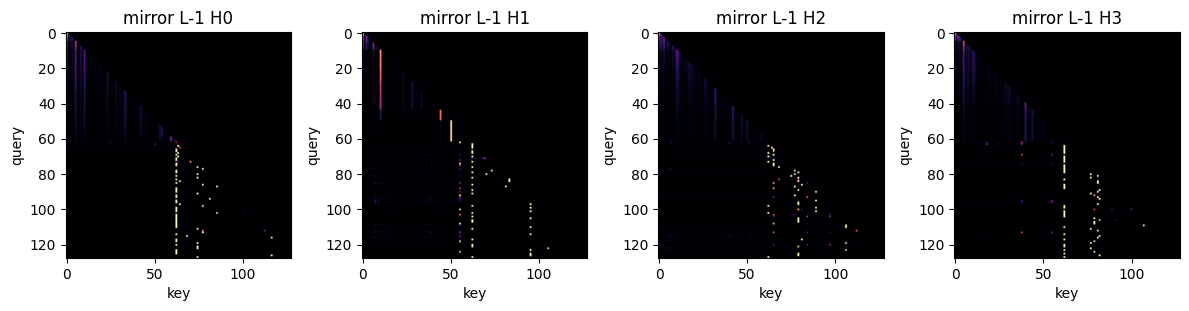

In [18]:
# Пример карт внимания: возьмём по 4 головы из последнего слоя каждой модели
for name in LANGS:
    A = get_attn(pretrained[name], EX[name])
    last = A[-1]                       # [H,S,S]
    H = last.shape[0]
    show = min(4, H)
    fig, axes = plt.subplots(1, show, figsize=(3.0 * show, 3.0))
    if show == 1:
        axes = [axes]
    for h in range(show):
        axes[h].imshow(last[h].numpy(), cmap="magma")
        axes[h].set_title(f"{name} L-1 H{h}")
        axes[h].set_xlabel("key")
        axes[h].set_ylabel("query")
    plt.tight_layout()
    plt.show()

### «Зеркальная голова»

Для языка `mirror` правильное внимание — **антидиагональ**: запрос в позиции `i` второй половины должен смотреть на симметричную позицию `len-1-i` первой половины. Найдём голову, которая сильнее всего смотрит на эту нужную позицию, и нарисуем её. Если такая голова есть — это наглядная находка: отдельная голова, которую породил именно наш язык.

Лучшая 'зеркальная' голова: слой 2, голова 12, масса на антидиагонали = 0.048


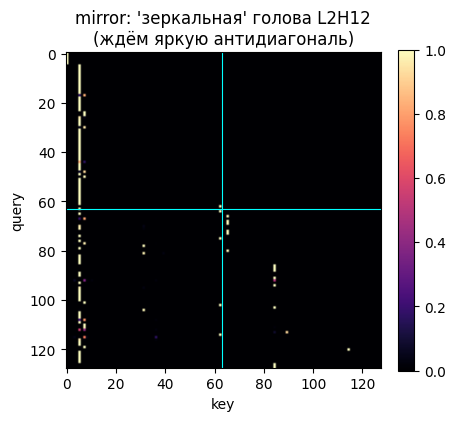

In [19]:
if "mirror" in LANGS:
    s = EX["mirror"]
    sep = 24                                  # n_sym=24 → SEP id
    sep_pos = s.index(sep)
    A = get_attn(pretrained["mirror"], s)
    # для каждой головы каждого слоя: средняя масса на зеркальной позиции среди запросов второй половины
    best = None
    for li, a in enumerate(A):
        Hh = a.shape[0]
        for h in range(Hh):
            vals = []
            for i in range(sep_pos + 1, 2 * sep_pos + 1):   # только реальная отражённая часть (без паддинга)
                mirror_key = 2 * sep_pos - i                # источник = отражённая позиция относительно SEP
                if 0 <= mirror_key < i:                     # каузально доступна
                    vals.append(a[h, i, mirror_key].item())
            score = np.mean(vals) if vals else 0.0
            if best is None or score > best[0]:
                best = (score, li, h)
    score, li, h = best
    print(f"Лучшая 'зеркальная' голова: слой {li}, голова {h}, масса на антидиагонали = {score:.3f}")
    plt.figure(figsize=(4.5, 4.5))
    plt.imshow(A[li][h].numpy(), cmap="magma")
    plt.axvline(sep_pos, color="cyan", lw=0.8)
    plt.axhline(sep_pos, color="cyan", lw=0.8)
    plt.title(f"mirror: 'зеркальная' голова L{li}H{h}\n(ждём яркую антидиагональ)")
    plt.xlabel("key")
    plt.ylabel("query")
    plt.colorbar(fraction=0.046)
    plt.show()
else:
    print("mirror не в списке LANGS — пропускаем.")

### Что показал анализ внимания

Структура синтетического языка определяет, какие «инструменты» осваивает тело трансформера:

- **`mirror` → самые дальнобойные и острые головы.** Максимальная дистанция внимания 54.0 и минимальная энтропия 0.01 — заметно выше остальных: у языка появляется одна очень длинная и очень сфокусированная голова.
- **`nested` / `flat_shuffle` / `counting` → короткие и средние головы** (макс. дистанция 36–42, без выраженного дальнобойного выброса). У `counting` головы самые размытые (энтропия 0.26) — внимание расплывается внутри счётного блока, а не бьёт в одну точку.

Но **чистой «зеркальной головы» в `mirror` не нашлось.** Само копирование язык выучивает почти идеально (pretrain ppl ≈ 4.8 — это близко к минимуму, который вообще возможен: первую половину строки угадать нельзя, вторая жёстко повторяет первую). Но лучшая голова кладёт на нужную антидиагональ всего ≈ 0.05 массы. На карте вместо диагонали копирования видна яркая вертикальная полоса на первых токенах (*attention sink*). То есть копирование в модели есть, но размазано по ней, а не собрано в одну понятную голову.

Главное: «дальнобойность» и «острота» у `mirror` максимальны — но переносу в английский (раздел 5) это **никак не помогает** (18%, худший язык). Карта внимания говорит, *чему* язык научил модель, но не о том, *насколько это полезно* для естественного языка. Это расхождение — «длинные и острые головы ≠ полезный перенос» — и есть один из главных результатов.

## 7. Расширение 3 — Обобщение на длины больше обучающей

Модель училась только на строках длины `L = 128`. Здесь проверяем, что происходит, когда на вход подаются строки **длиннее** виденных при обучении: насколько деградирует качество за пределами обучающей длины.

`mirror` удобен тем, что задаёт однозначную цель на каждой позиции второй половины (это отражённый токен первой половины), поэтому «точность восстановления» легко померить для любой длины строки. У GPT-Neo позиционные эмбеддинги для позиций `> 128` при обучении не встречались, так что это честный тест на экстраполяцию по длине.

In [ ]:
@torch.no_grad()
def mirror_reconstruction(model, L, n_sym=24, n_eval=200):
    """Доля верно восстановленных отражённых токенов для строк длины L."""
    half = (L - 1) // 2
    r = random.Random(7)
    correct = 0
    total = 0
    for _ in range(n_eval):
        S = [r.randrange(n_sym) for _ in range(half)]
        seq = S + [n_sym] + S[::-1]
        pred = model(input_ids=torch.tensor([seq], device=DEVICE)).logits[0].argmax(-1)
        for pos in range(half + 1, 2 * half + 1):     # вторая половина = отражение первой
            correct += int(pred[pos - 1].item() == seq[pos])
            total += 1
    return correct / total

if "mirror" in LANGS:
    train_L = CONFIG["seq_syn"]
    lengths = [64, 96, train_L, 160, 192, 224, 256]
    accs = [mirror_reconstruction(pretrained["mirror"], L) for L in lengths]

    plt.figure(figsize=(6.4, 4))
    plt.plot(lengths, accs, marker="o")
    plt.axvline(train_L, color="gray", ls="--", lw=1.2, label=f"длина обучения = {train_L}")
    plt.axhline(1 / 24, color="r", ls=":", lw=1, label="случайный выбор")
    plt.xlabel("длина последовательности (токены)")
    plt.ylabel("точность восстановления")
    plt.title("mirror: деградация за пределами обучающей длины")
    plt.ylim(0, 1.02)
    plt.legend()
    plt.grid(alpha=.3)
    plt.show()

    in_train = np.mean([a for L, a in zip(lengths, accs) if L <= train_L])
    beyond = np.mean([a for L, a in zip(lengths, accs) if L > train_L])
    print(f"В пределах обучающей длины (L ≤ {train_L}): acc = {in_train:.2f}")
    print(f"За пределами обучающей длины (L > {train_L}): acc = {beyond:.2f}")
else:
    print("mirror не в списке LANGS — пропускаем.")

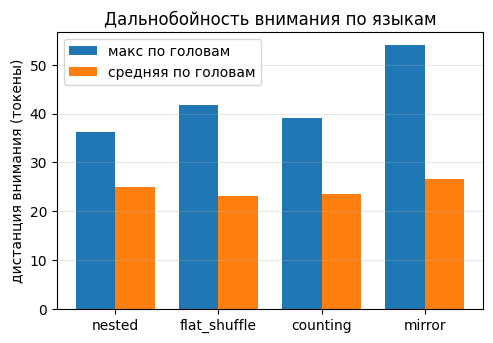

In [ ]:
# Сводный «дальнобойный потенциал»: макс. и средняя дистанция внимания по моделям
plt.figure(figsize=(5.5, 3.6))
names = list(attn_stats.keys())
maxd = [attn_stats[n]["dist"].max().item() for n in names]
meand = [attn_stats[n]["dist"].mean().item() for n in names]
x = np.arange(len(names))
w = 0.38
plt.bar(x - w / 2, maxd, w, label="макс по головам")
plt.bar(x + w / 2, meand, w, label="средняя по головам")
plt.xticks(x, names)
plt.ylabel("дистанция внимания (токены)")
plt.title("Дальнобойность внимания по языкам")
plt.legend()
plt.grid(alpha=.3, axis="y")
plt.show()

## 8. (Бонус) Изотропность эмбеддингов

Статья смотрит спектр сингулярных чисел и кластеры. Добавляем количественные метрики на эмбеддингах, дообученных на английском в режиме **E** (как в статье для проб):

- **Participation Ratio** $\mathrm{PR} = \dfrac{(\sum_i \sigma_i)^2}{\sum_i \sigma_i^2}$ — «эффективная размерность» (выше → пространство используется полнее).
- **eff_dim_ratio** = PR / `d` — доля от 256 измерений.
- **top1 / top5** — доля дисперсии в 1 / 5 главных компонентах (ниже → менее «сплюснуто»).
- **mean|cos|** — средний модуль косинуса между случайными токенами (ниже → изотропнее).

Гипотеза: более сложные языки дают геометрически более «здоровые» (изотропные, высокоразмерные) эмбеддинги, ближе к `scratch`.

In [ ]:
def isotropy(E):
    E = E.float()
    E = E - E.mean(0, keepdim=True)
    s = torch.linalg.svdvals(E)
    var = s.pow(2)
    var = var / var.sum()
    pr = (s.sum() ** 2) / (s.pow(2).sum())
    En = F.normalize(E, dim=1)
    r = torch.Generator().manual_seed(0)
    idx = torch.randint(0, E.size(0), (2, 5000), generator=r)
    cos = (En[idx[0]] * En[idx[1]]).sum(-1)
    return dict(participation_ratio=round(pr.item(), 1),
                eff_dim_ratio=round(pr.item() / E.size(1), 3),
                top1=round(var[0].item(), 3),
                top5=round(var[:5].sum().item(), 3),
                mean_abs_cos=round(cos.abs().mean().item(), 3))

iso_rows = []
for name, E in en_embeddings.items():
    row = isotropy(E)
    row["model"] = name
    iso_rows.append(row)
iso_df = pd.DataFrame(iso_rows).set_index("model")
display(iso_df)

# спектры
plt.figure(figsize=(6, 4))
for name, E in en_embeddings.items():
    Ec = E.float() - E.float().mean(0)
    s = torch.linalg.svdvals(Ec)
    s = s / s.max()
    plt.plot(s[:60].numpy(), label=name)
plt.yscale("log")
plt.xlabel("индекс сингулярного числа")
plt.ylabel("нормированное σ (log)")
plt.title("Спектр эмбеддингов (E-режим, англ.)")
plt.legend()
plt.grid(alpha=.3)
plt.show()

## 9. Выводы

Все сравнения — с доверительными интервалами (3 сида, профиль `fast_ci`) и против двух языков статьи (`nested`, `flat_shuffle`). `scratch` = 59.9 ppl (= 100%). Числа ниже — из этого прогона.

### Главный результат

**Лучше всех переносится иерархия — `nested` (101 ± 6%, на уровне scratch), и наши новые языки её не побили.** `flat_shuffle` — 90 ± 3%, `counting` — 80 ± 12%, `mirror` — 18 ± 3%: оба языка статьи выше обоих наших новых. Это и есть ценность сильных бейзлайнов вместе с мульти-сидом — они не дали сделать преждевременный вывод «мой язык лучший». Ценность работы не в победе, а в находках.

### Находки

1. **`counting` дотягивает до `flat_shuffle`, но не до иерархии и менее стабилен.** Вердикт: `counting` ≈ `flat_shuffle` (НЕРАЗЛИЧИМО, Δ = −10%), но `counting` < `nested` (ХУЖЕ, Δ = −21%). Разброс `counting` самый большой (12%, один сид просел до 66%), а `flat_shuffle` — самый тесный (3%). То есть новый «навыковый» язык выходит на уровень сильнейшего языка статьи, но повторяется от сида к сиду хуже, и до иерархии не дотягивает.
2. **Сложность языка ≠ польза — это главный вывод.** `mirror` стабильно худший (18%), хотя копирование он выучивает почти идеально (pretrain ppl ≈ 4.8 — близко к возможному минимуму) и по вниманию у него самые дальнобойные/острые головы. Полезны иерархия, структура и счёт — а **не** дословное копирование.
3. **Внимание объясняет механизм, но не пользу.** `mirror` даёт самые длинные (54.0) и острые (энтропия 0.01) головы; `nested` / `flat_shuffle` / `counting` держатся рядом (36–42). При этом чистой, понятной «зеркальной головы» не нашлось — на карте вместо неё attention sink (масса на антидиагонали ≈ 0.05). Структура языка задаёт, *чему* модель учится, но не то, *насколько* это полезно для языка.

### Что из этого следует — про методологию обучения

Раз разные языки прокачивают **разные** умения (иерархию, счёт, долгую память) и эти умения почти не пересекаются, искать один «лучший для всего» синтетический язык — похоже, неправильная постановка. Перспективнее **смешивать** языки: обучать тело на наборе разных синтетик, меняя их **пропорции** и **порядок** подачи (curriculum), чтобы модель забрала сразу несколько полезных умений, а не одно. Проверка такой смеси и расписания — естественное продолжение работы.

### Честные оговорки

- **cloze-accuracy слабо различает языки.** Выделяется только `nested` (69 ± 2%, единственный выше scratch 62%); `flat_shuffle` / `counting` / `mirror` держатся на 58–60% (интервалы перекрываются). Все выше 50% — даже замороженное синтетическое тело уже даёт понимание выше случайного. Реально разделяет языки только Efficiency (ppl).
- **`nested` исторически нестабилен между прогонами.** Здесь он лучший и довольно тесный (6%), но в прежних прогонах его разброс бывал много больше — для уверенного вывода «иерархия лучшая» нужны ≥5 сидов и `PROFILE="convergence"`.
- Анализ внимания считается на сиде 0; разделы 7 (экстраполяция по длине) и 8 (изотропия) в этом прогоне не пересчитывались — их стоит запустить отдельно.

### Формулировка вклада

*Мы вводим синтетические языки под конкретные навыки (счёт, долгая память), метрику эффективности переноса с доверительными интервалами и сравнение с языками статьи. Главное: (1) лучше всех переносится иерархия, а наши новые языки её не превосходят — счёт дотягивает лишь до `flat_shuffle`; (2) то, что язык сложнее устроен, не делает его полезнее для английского (почти идеальное копирование `mirror` бесполезно, 18%); (3) анализ внимания показывает, как структура языка определяет, чему модель учится, но «сложные» головы не означают полезный перенос; (4) практический вывод — обучать стоит на смеси разных синтетик, а не искать один универсальный язык.*

## 10. Дальнейшие шаги


- **Сходимость.** `PROFILE="convergence"` (шаги уровня статьи, 15–30K претрейна) и ≥5 сидов → узкие интервалы и t-тест вместо грубого критерия.
- **Смесь синтетик.** Обучать тело сразу на нескольких языках, меняя их пропорции и порядок подачи (curriculum), и проверить, складываются ли полезные умения (счёт + иерархия + …) в перенос сильнее, чем у любого языка по отдельности. Прямо следует из находки раздела 9: разные языки дают разные умения.
- **Масштабирование модели.** Повторить на TinyStories 8M → 33M → 100M: усиливается или исчезает эффект.
- **Связать внимание с английским.** Тест subject–verb agreement через `k` вставленных слов — переносится ли «дальнобойность» из раздела 6 на реальный английский.
- **Язык под гипотезу.** Раз английскому нужны не копии, а *согласование признака* на расстоянии — добавить язык `agreement`: токен должен повторить **признак** (а не сам токен) раннего токена через отвлекающие вставки. Кандидат «побить `flat_shuffle`», мотивированный находкой из раздела 9.
- **Аблации** компонентов `counting` / `mirror` (счёт vs память по отдельности).